In [15]:
import numpy
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
path = '.\data of biofilm(TINON BHAI).xlsx'
full_df  = pd.read_excel('.\data of biofilm(TINON BHAI).xlsx', sheet_name = "catkin")


In [7]:
full_df

,absorbance,Ce,Initial concentration,Co-Ce,Qe,LN CE,LN QE,Ce/Qe,removal percentage(catkin)
0,0.18283,12.53496,20,7.46504,0.74650,2.52852,-0.29235,16.79156,37.32519
1,0.28417,18.60877,30,11.39123,1.13912,2.92363,0.13026,16.33604,37.97078
2,0.38148,24.44128,40,15.55872,1.55587,3.19627,0.44204,15.70905,38.89681
3,0.46373,29.37121,50,20.62879,2.06288,3.38002,0.72410,14.23797,41.25757
4,0.56008,35.14635,60,24.85365,2.48536,3.55952,0.91042,14.14133,41.42274


In [10]:
import numpy as np
full_df_ic = np.array(full_df["Initial concentration"])
full_df_ic

array([20, 30, 40, 50, 60])

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_full_df_ic = scaler.fit_transform(full_df_ic.reshape(-1,1))
#unsclaed_full_df_ic =
# reverse the scaling
denormalized_full_df_ic = scaler.inverse_transform(scaled_full_df_ic)
denormalized_full_df_ic,scaled_full_df_ic

(array([[20.],
        [30.],
        [40.],
        [50.],
        [60.]]),
 array([[-1.41421356],
        [-0.70710678],
        [ 0.        ],
        [ 0.70710678],
        [ 1.41421356]]))

In [ ]:
"""
Kinetics data:
    Input: Time
    Output: Adsorption(qt)
"""

'\nKinetics data:\n'

In [ ]:
kinetics_df = pd.read_excel(path, sheet_name = 'catkin (pfo pso)')
kinetics_df

,Time,qt( catkin)
0,0,0.00000
1,10,0.72145
2,20,0.84218
3,30,0.85548
4,50,0.88510
5,80,0.99843
6,110,1.10776
7,140,1.15607
8,170,1.17853


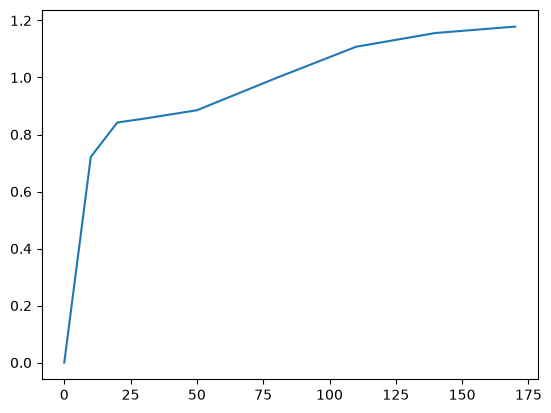

In [19]:
# plot the relation
import matplotlib.pyplot as plt
plt.plot(kinetics_df['Time'].values, kinetics_df['qt( catkin)'].values)

In [ ]:
## Normalize the value and test the model
## Start picking models
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error

X, y = kinetics_df['Time'].values, kinetics_df['qt( catkin)'].values
# Do the scaling



(array([  0,  10,  20,  30,  50,  80, 110, 140, 170]),
 array([0.     , 0.72145, 0.84218, 0.85548, 0.8851 , 0.99843, 1.10776,
        1.15607, 1.17853]))

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV


pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('preprocessing', StandardScaler()),
    ('model', LinearRegression())
])

param_grid = {
    'poly__degree': [1, 2, 3]
}

loo = LeaveOneOut()
grid_search_model = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv = loo,
    scoring = 'r2'
)

grid_search_model.fit(X.reshape(-1,1),y)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'poly__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",LeaveOneOut()
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fi

In [25]:
grid_search_model.score

<bound method BaseSearchCV.score of GridSearchCV(cv=LeaveOneOut(),
             estimator=Pipeline(steps=[('poly', PolynomialFeatures()),
                                       ('preprocessing', StandardScaler()),
                                       ('model', LinearRegression())]),
             param_grid={'poly__degree': [1, 2, 3, 4, 5]}, scoring='r2')>

In [28]:
grid_search_model.cv_results_

{'mean_fit_time': array([0.00696198, 0.00163036, 0.00151685, 0.0012433 , 0.00121389]),
 'std_fit_time': array([1.26291165e-02, 6.75825328e-04, 2.93637589e-04, 1.00525646e-04,
        9.22374288e-05]),
 'mean_score_time': array([0.00175481, 0.00054497, 0.00057936, 0.00052381, 0.00050076]),
 'std_score_time': array([2.20061065e-03, 6.00429713e-05, 6.90112772e-05, 2.84805715e-05,
        1.60295005e-05]),
 'param_poly__degree': masked_array(data=[1, 2, 3, 4, 5],
              mask=[False, False, False, False, False],
        fill_value=999999),
 'params': [{'poly__degree': 1},
  {'poly__degree': 2},
  {'poly__degree': 3},
  {'poly__degree': 4},
  {'poly__degree': 5}],
 'split0_test_score': array([nan, nan, nan, nan, nan]),
 'split1_test_score': array([nan, nan, nan, nan, nan]),
 'split2_test_score': array([nan, nan, nan, nan, nan]),
 'split3_test_score': array([nan, nan, nan, nan, nan]),
 'split4_test_score': array([nan, nan, nan, nan, nan]),
 'split5_test_score': array([nan, nan, nan, na

In [29]:
grid_search_model.best_score_

np.float64(nan)